# Movies Data Analysis

This notebook walks you through:

1. **Data Loading**
2. **Data Cleaning**
3. **Exploratory Data Analysis**
4. **Data Preprocessing**



## Step 1: Data Loading

- **Objective:** Load your dataset into a DataFrame and perform initial inspections.
- **Actions:**
  - Replace the `data_path` with the correct file path or connection string.
  - Inspect the shape and data types, preview rows.

In [1]:
import pandas as pd
import numpy as np

# wheres the data
data_path = "./enhanced_box_office_data(2000-2024)u.csv"
# Load data
df = pd.read_csv(data_path)

# Initial inspection
print("Shape:", df.shape)
print("Data types:\n", df.dtypes)
df.head()

Shape: (5000, 13)
Data types:
 Rank                      int64
Release Group            object
$Worldwide              float64
$Domestic               float64
Domestic %              float64
$Foreign                float64
Foreign %               float64
Year                      int64
Genres                   object
Rating                   object
Vote_Count              float64
Original_Language        object
Production_Countries     object
dtype: object


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


## Step 2: Data Cleaning & Preprocessing

- **Objective:** Identify and handle missing values, duplicates, and inconsistent entries.
- **Actions:**
  - Compute missingness percentages.
  - Drop or impute missing data as appropriate.
  - Remove duplicates or inconsistent records.

In [2]:
# 1) Compute and display initial missingness
missing_pct = df.isna().mean() * 100
print("Initial missing values (%):\n", missing_pct)

# 2) Drop rows with ANY missing values
#    Since each column has <5% missing, for simplicity we can safely remove those rows.
df_clean = df.dropna()
print(f"\nAfter dropping missing rows, new shape: {df_clean.shape}")

# 3) Recompute and display missingness to confirm cleanup
missing_pct_after = df_clean.isna().mean() * 100
print("Missing values after drop (%):\n", missing_pct_after)

# 4) Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# 5) (Optional) Drop duplicates if any exist
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Dropped {duplicates} duplicates; new shape: {df_clean.shape}")
# 6) Column renaming & spelling corrections 
df_clean = df_clean.rename(columns=lambda s: s.replace('$','')
                                         .replace('%','percent')
                                         .replace(' ','_'))
# Example spelling fixes (extend as needed)
# df_clean['Original_Language'] = df_clean['Original_Language'].replace({'Englsh':'English'})

# 7) Convert 'Rating' column from text to numeric and impute missing values
df_clean['Rating'] = df_clean['Rating'].str.split('/').str[0].astype(float)


Initial missing values (%):
 Rank                    0.00
Release Group           0.00
$Worldwide              0.00
$Domestic               0.00
Domestic %              0.00
$Foreign                0.00
Foreign %               0.00
Year                    0.00
Genres                  3.56
Rating                  3.40
Vote_Count              3.40
Original_Language       3.40
Production_Countries    4.00
dtype: float64

After dropping missing rows, new shape: (4797, 13)
Missing values after drop (%):
 Rank                    0.0
Release Group           0.0
$Worldwide              0.0
$Domestic               0.0
Domestic %              0.0
$Foreign                0.0
Foreign %               0.0
Year                    0.0
Genres                  0.0
Rating                  0.0
Vote_Count              0.0
Original_Language       0.0
Production_Countries    0.0
dtype: float64

Number of duplicate rows: 0


## Step 3: Exploratory Data Analysis (EDA)

**Objective:**  
- Understand the distributions, outliers, and relationships in our cleaned data.

**Actions:**  
1. Plot histograms and boxplots for all numeric features.  
2. Plot bar charts of the top 10 levels for each categorical feature.  
3. Display a scatter-matrix of numeric features to spot pairwise patterns.  
4. Examine the time trend of average Domestic revenue by release year.  

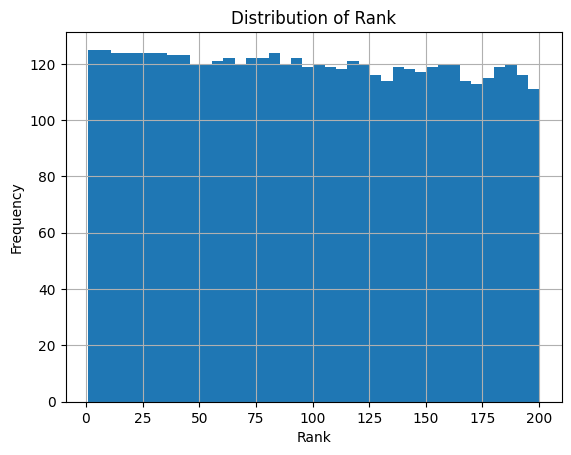

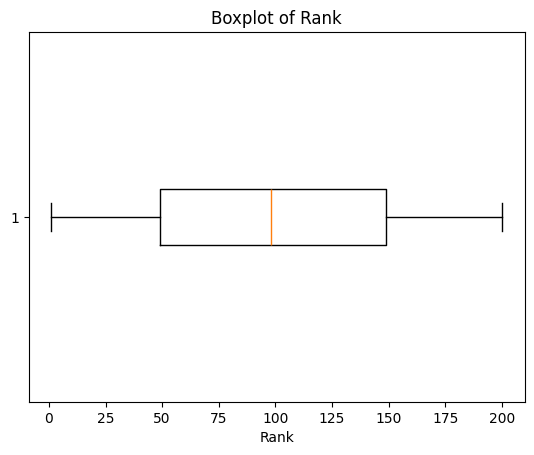

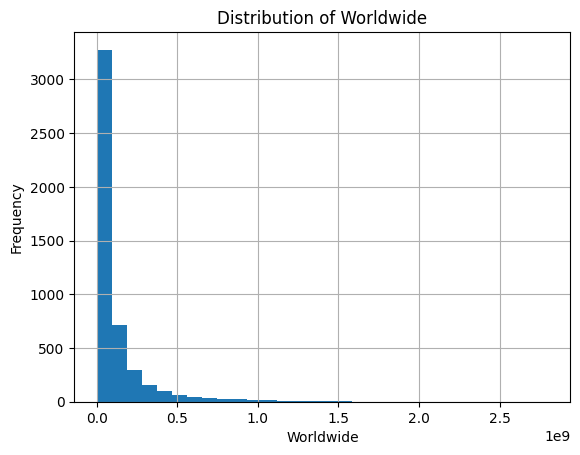

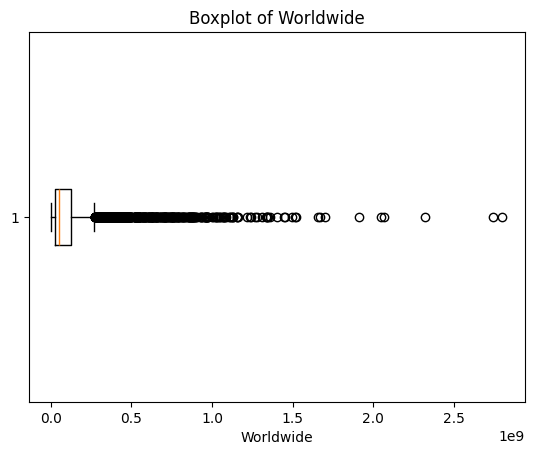

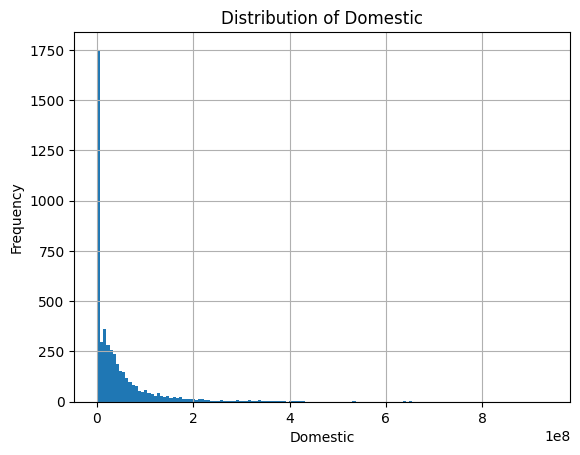

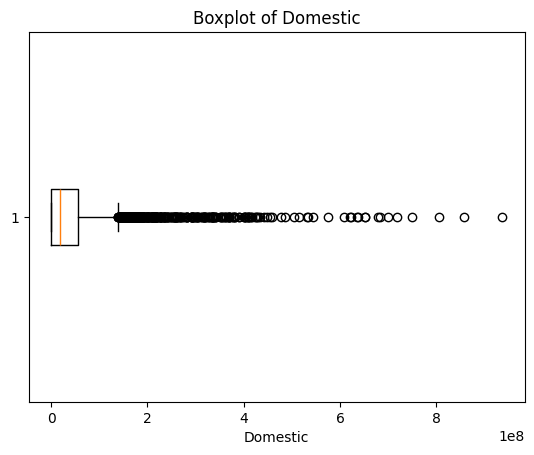

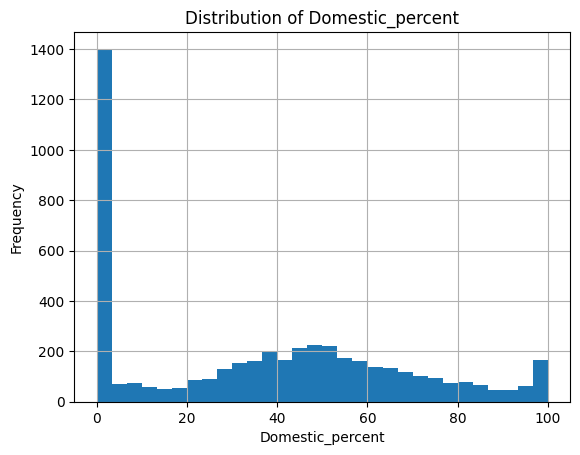

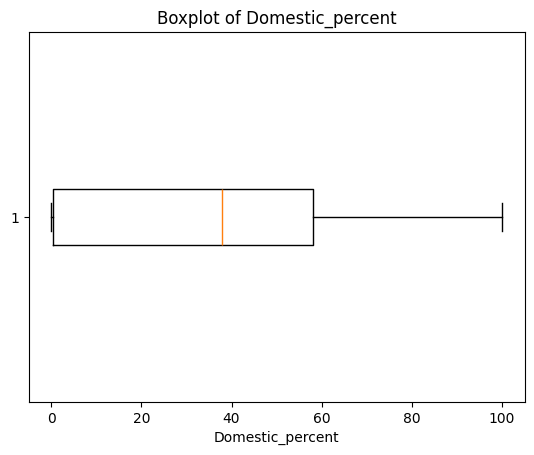

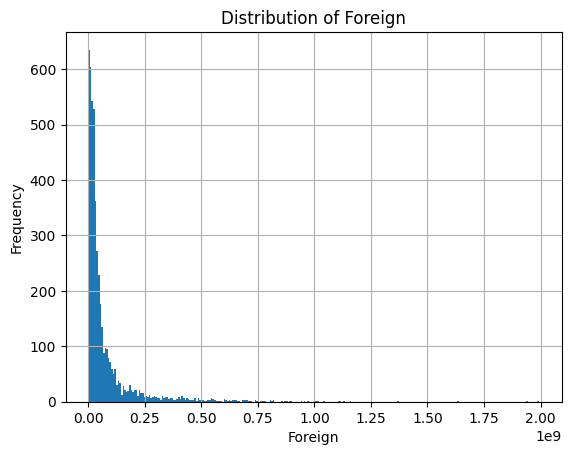

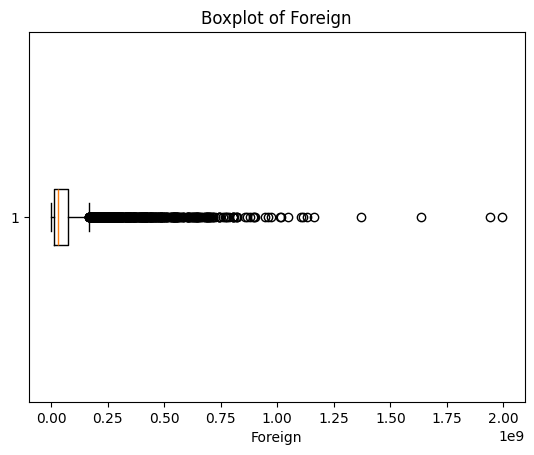

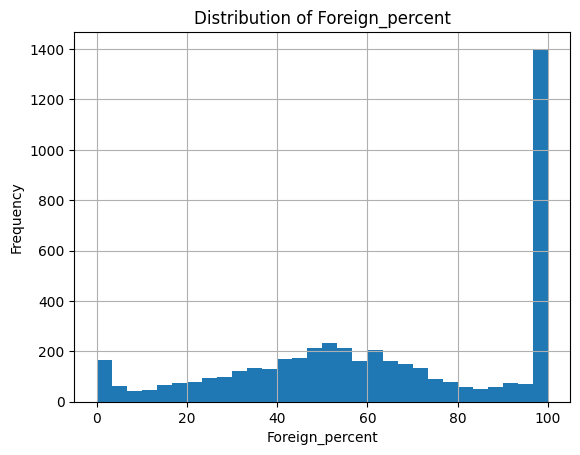

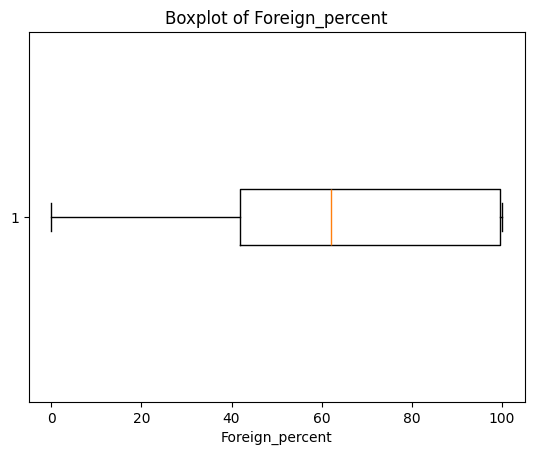

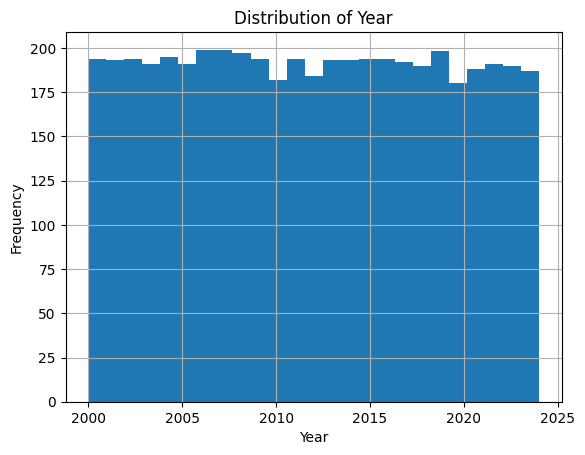

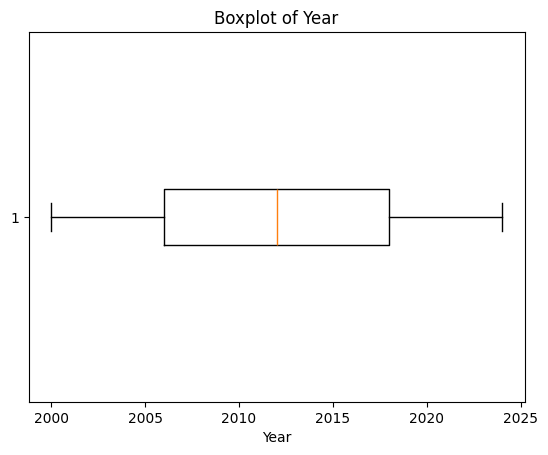

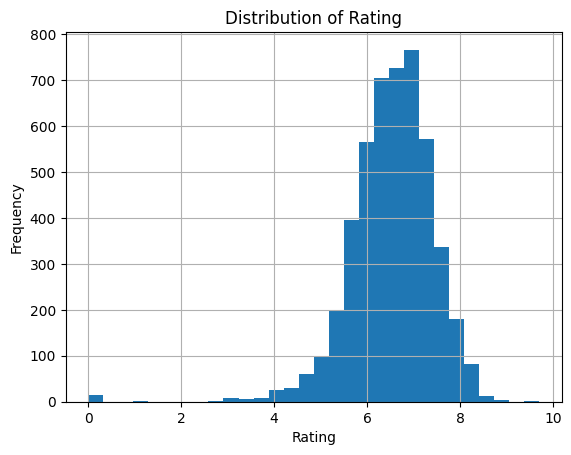

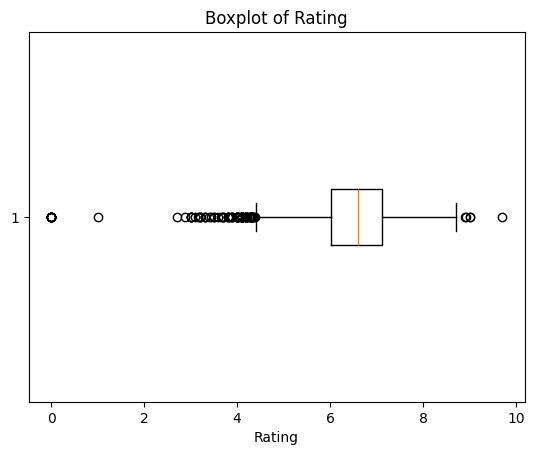

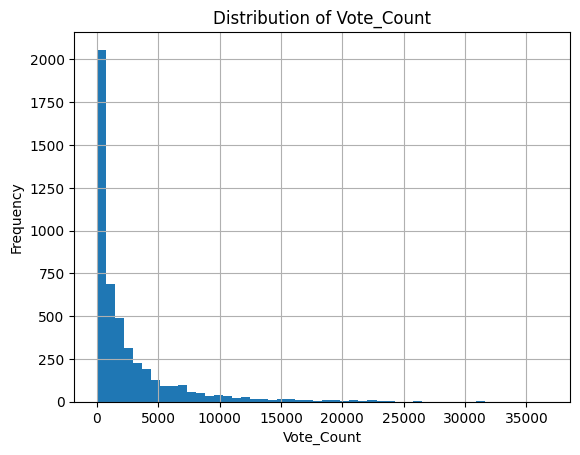

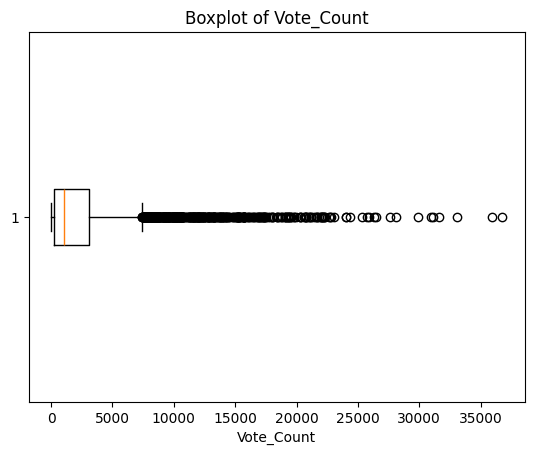

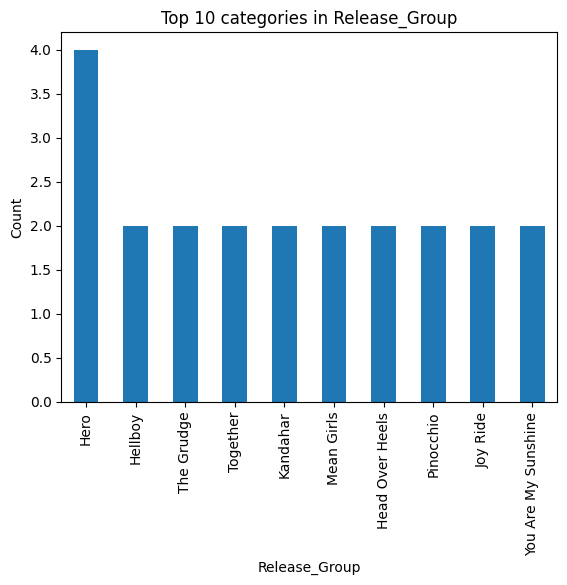

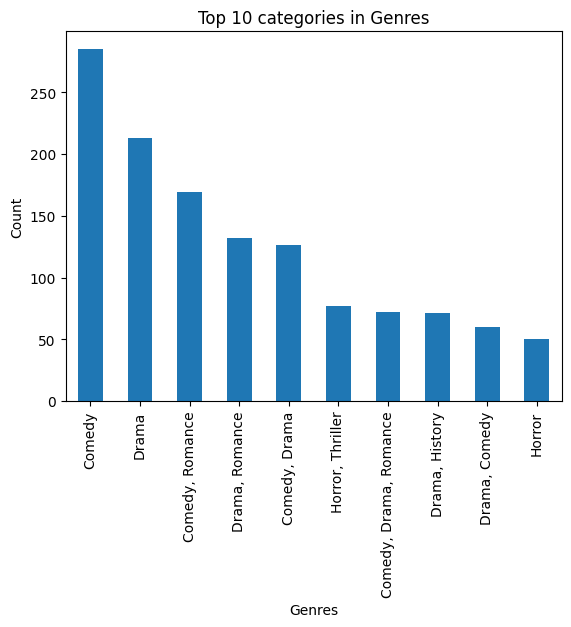

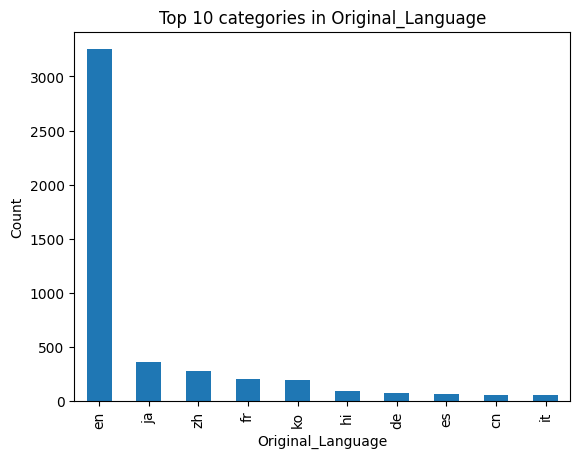

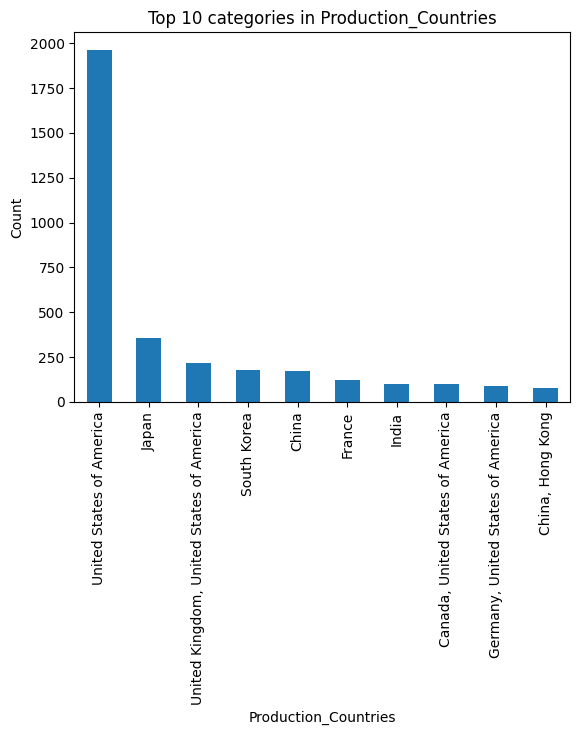

<Figure size 1200x1200 with 0 Axes>

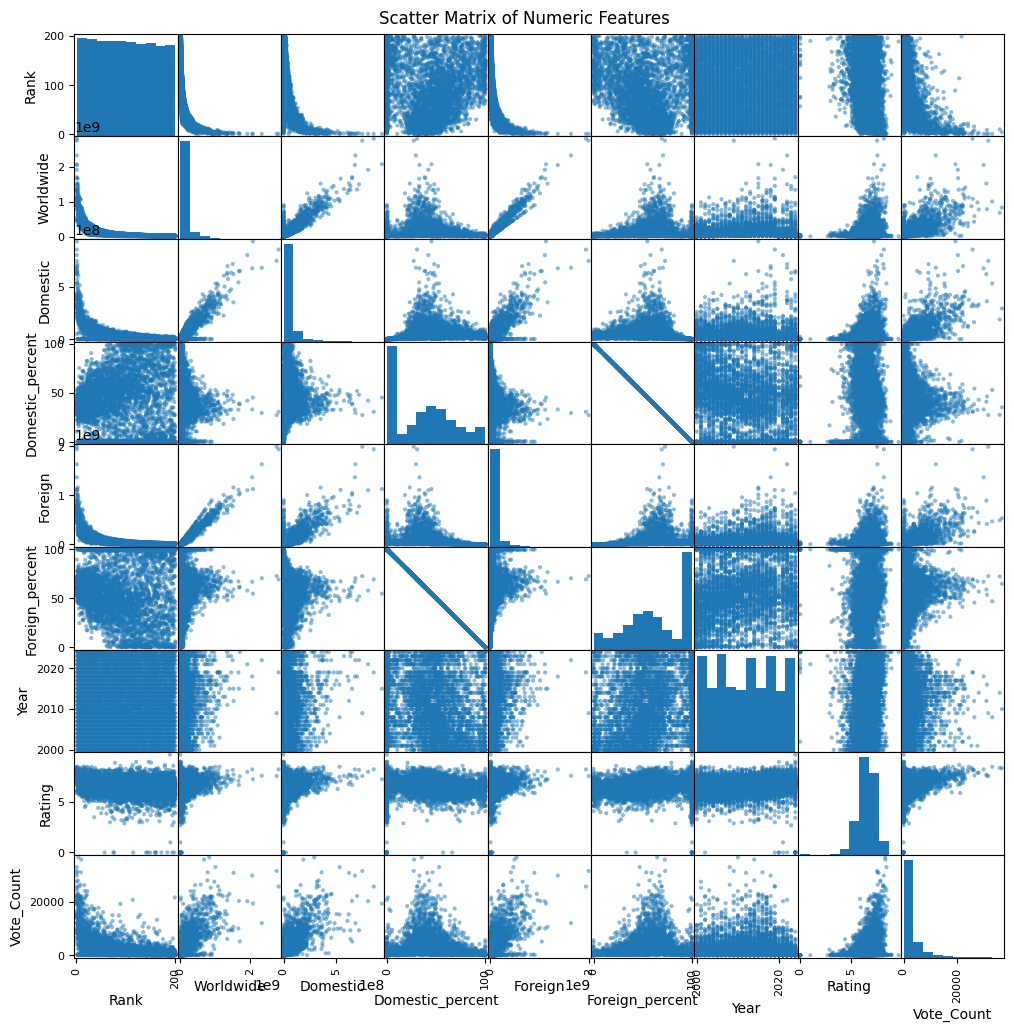

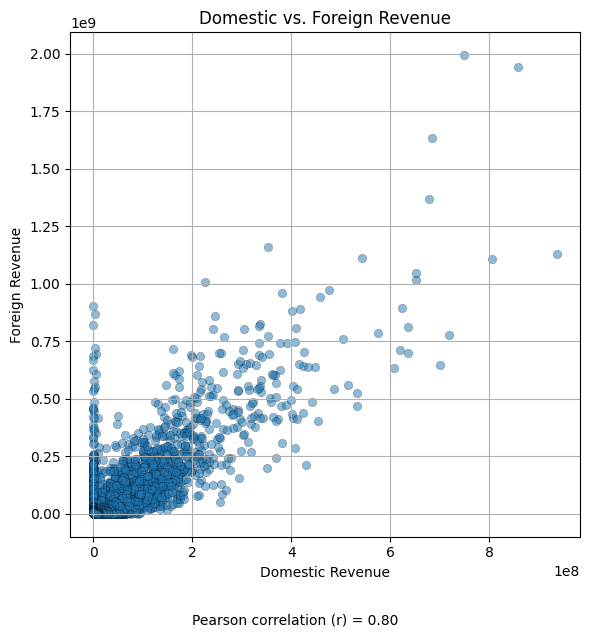

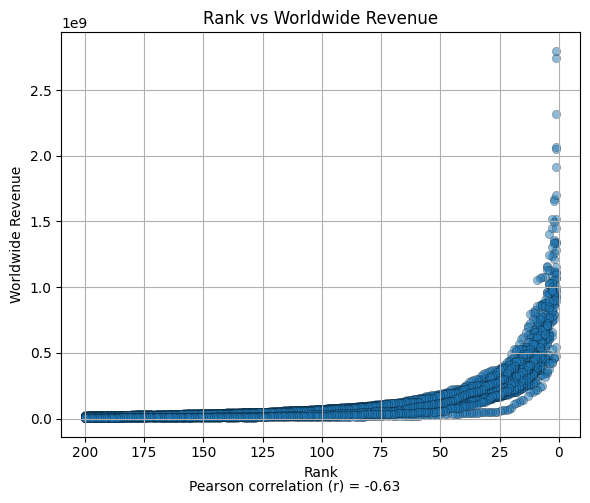

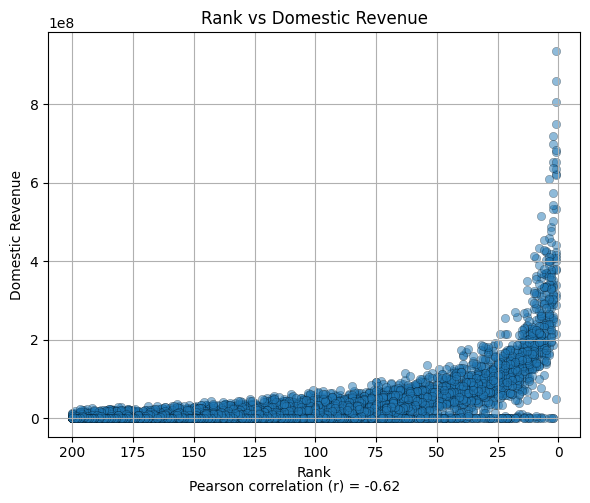

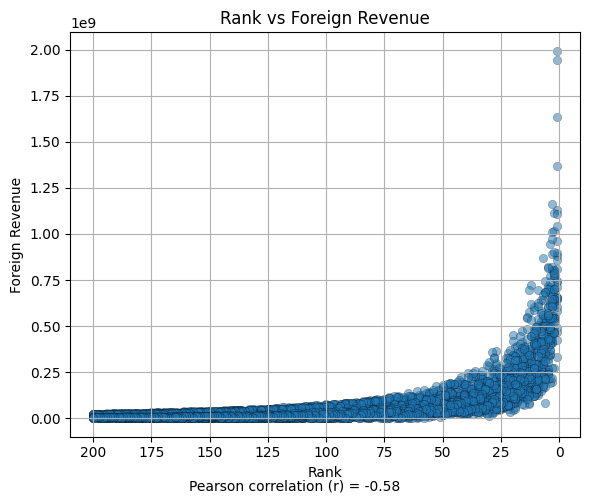

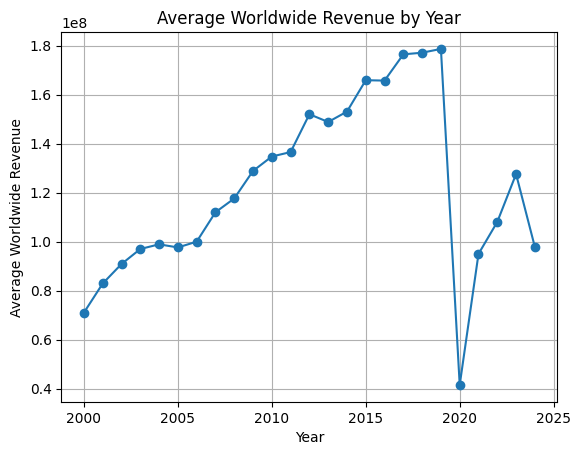

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pandas.plotting import scatter_matrix

# 1) Identify your numeric and categorical columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# 2a) Define how many bins you want for each numeric column
bins_map = {
    'Rank': 40,
    'Year': 25,           # e.g. one bin per 2–3 years
    'Domestic': 'auto',   # let numpy decide a reasonable rule
    'Foreign': 'auto',
    'Vote_Count': 50,
    # add others if needed…
}

# 2b) Loop and apply per-col bins
for col in num_cols:
    bin_setting = bins_map.get(col, 30)  # default to 30 if not in map
    
    # Histogram
    plt.figure()
    df_clean[col].hist(bins=bin_setting, density=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    
    # Boxplot
    plt.figure()
    plt.boxplot(df_clean[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()
    
# 3) Bar charts for top levels of categorical features
for col in cat_cols:
    top_vals = df_clean[col].value_counts().nlargest(10)
    plt.figure()
    top_vals.plot(kind='bar')
    plt.title(f'Top 10 categories in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# 4) Scatter-matrix for numeric features
plt.figure(figsize=(12, 12))
scatter_matrix(df_clean[num_cols], diagonal='hist', figsize=(12,12))
plt.suptitle('Scatter Matrix of Numeric Features', y=0.9)
plt.show()
# 4.1) Scatter plot: Domestic vs Foreign

corr = df_clean['Domestic'].corr(df_clean['Foreign'])

plt.figure(figsize=(6, 6))
plt.scatter(
    df_clean['Domestic'], 
    df_clean['Foreign'], 
    alpha=0.5,           # transparency to help with overplotting
    edgecolor='k',       # subtle point borders
    linewidth=0.3
)
plt.title('Domestic vs. Foreign Revenue')
plt.xlabel('Domestic Revenue')
plt.ylabel('Foreign Revenue')
plt.grid(True)
#    Add caption with correlation coefficient
#    Place it just below the axes (you may need to tweak the y-position)
plt.figtext(
    0.5, -0.05,
    f'Pearson correlation (r) = {corr:.2f}',
    ha='center',
    fontsize=10
)
plt.tight_layout()
plt.show()

# 4.2) Scatter plots: Rank vs Global, Domestic, Foreign

metrics = ['Worldwide', 'Domestic', 'Foreign']

for metric in metrics:
    x = df_clean['Rank']
    y = df_clean[metric]
    
    # compute Pearson r
    r = x.corr(y)
    
    # create figure
    plt.figure(figsize=(6, 5))
    plt.scatter(
        x, y,
        alpha=0.5,
        edgecolor='k',
        linewidth=0.3
    )
    plt.title(f'Rank vs {metric} Revenue')
    plt.xlabel('Rank')
    plt.ylabel(f'{metric} Revenue')
    plt.grid(True)
    plt.gca().invert_xaxis()  # optional: puts Rank=1 on the left
    
    # add caption below axes
    plt.figtext(
        0.5, 0.01,  # x=0.5 center, y=0.01 just below the plot
        f'Pearson correlation (r) = {r:.2f}',
        ha='center',
        fontsize=10
    )
    
    plt.tight_layout()
    plt.show()


# 5) Time Trend: average Domestic revenue by Year
if 'Worldwide' in df_clean.columns and 'Year' in df_clean.columns:
    yearly_dom = df_clean.groupby('Year')['Worldwide'].mean()
    plt.figure()
    plt.plot(yearly_dom.index, yearly_dom.values, marker='o')
    plt.title('Average Worldwide Revenue by Year')
    plt.xlabel('Year')
    plt.ylabel('Average Worldwide Revenue')
    plt.grid(True)
    plt.show()

## Step 4: Data Preprocessing & Feature Engineering

**Objective:**  
- Predict three continuous targets:  
  1. Global revenue (`Worldwide`)  
  2. Domestic revenue (`Domestic`)  
  3. Foreign revenue (`Foreign`)  
- Stabilize variance by modeling their **log₁₊ₓ** transforms.  
- Encapsulate all transforms in a reproducible scikit-learn pipeline.  
- Split into train/test to avoid leakage.

**Actions:**  
1. **Create** `log_Worldwide`, `log_Domestic`, and `log_Foreign` in `df_fe`.  
2. **Engineer** other features:  
   - `Rank_norm` (within-year ranking)  
   - raw `Year` and raw `Rating` (to be standardized in the pipeline)  
   - top-5 language + “Other”  
   - multi-hot dummies for genres & production countries  
3. **Drop** the raw revenue columns (`Worldwide`, `Domestic`, `Foreign`) but **keep** the log targets.  
4. Define `X` (all engineered features) and `y` (the three `log_…` targets).  
5. **Build** a `ColumnTransformer` + `Pipeline` that:  
   - **Standardizes** numeric features (`Rank_norm`, `Year`, `Rating`)  
   - **One-hot encodes** all categorical dummies  
6. **Train/test split** `X` and `y`; then  
   - `.fit_transform()` the pipeline on `X_train`  
   - `.transform()` the pipeline on `X_test`

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# — 0) Working copy —
df_fe = df_clean.copy()

# — 0b) Recompute global revenue —
df_fe['Worldwide'] = df_fe['Domestic'] + df_fe['Foreign']


# — 0b.5) Outlier Detection & Winsorization —  (insert this right after "— 0b) Recompute global revenue —")

from scipy.stats.mstats import winsorize

# 1) Flag 99th-percentile outliers
for col in ['Worldwide', 'Domestic', 'Foreign']:
    q99 = df_fe[col].quantile(0.99)
    df_fe[f'{col}_outlier_flag'] = df_fe[col] > q99

# 2) Winsorize at the 0.5% tails
for col in ['Worldwide', 'Domestic', 'Foreign']:
    df_fe[col] = winsorize(df_fe[col], limits=[0.005, 0.005])

    
# — 1) Create log-transformed targets —
for col in ['Worldwide', 'Domestic', 'Foreign']:
    df_fe[f'log_{col}'] = np.log1p(df_fe[col])

# — 2) Feature engineering —
# 2a) Normalize Rank within each Year
df_fe['Rank_norm'] = df_fe.groupby('Year')['Rank'] \
                          .transform(lambda x: (x - x.min()) / (x.max() - x.min()))


# 2c) Top-5 languages + Other
top_langs = df_fe['Original_Language'].value_counts().nlargest(5).index
df_fe['Original_Language'] = df_fe['Original_Language'] \
                               .where(df_fe['Original_Language'].isin(top_langs), 'Other')

# 2d) Multi-hot Genres & Production_Countries
genre_dummies   = df_fe['Genres'].str.get_dummies(sep='|')
country_dummies = df_fe['Production_Countries'].str.get_dummies(sep='|')
df_fe = pd.concat([df_fe, genre_dummies, country_dummies], axis=1)


# — 3) Drop raw & redundant columns (but keep Year & Rating!) —
drop_cols = [
    'Worldwide','Domestic','Foreign',
    'Domestic_percent','Foreign_percent','Rank',
    # 'Year',         <-- remove Year from drop list
    'Release_Group','Genres','Production_Countries'
]
df_fe.drop(columns=[c for c in drop_cols if c in df_fe], inplace=True)

# — 4) Define X and y —
target_cols  = ['log_Worldwide', 'log_Domestic', 'log_Foreign']
feature_cols = [c for c in df_fe.columns if c not in target_cols]

X = df_fe[feature_cols]
y = df_fe[target_cols]

# — 5) Build preprocessing pipeline for X —
numeric_feats     = ['Rank_norm','Year','Rating']   # feed raw Year & Rating here
categorical_feats = ['Original_Language'] \
                  + genre_dummies.columns.tolist() \
                  + country_dummies.columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_feats)
])

pipeline = Pipeline(steps=[('preproc', preprocessor)])

# — 6) Train/test split & transform —
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=42
)

X_train_prepped = pipeline.fit_transform(X_train)
X_test_prepped  = pipeline.transform(X_test)

print("Preprocessing complete.")
print("  • X_train_prepped shape:", X_train_prepped.shape)
print("  • X_test_prepped  shape:", X_test_prepped.shape)
print("  • y_train shape:", y_train.shape)
print("  • y_test  shape:", y_test.shape)

Preprocessing complete.
  • X_train_prepped shape: (1918, 2834)
  • X_test_prepped  shape: (2879, 2834)
  • y_train shape: (1918, 3)
  • y_test  shape: (2879, 3)


## Step 5: Unified Model Training & Evaluation

In this step, we standardize and streamline our end-to-end modeling workflow by:

1. **Defining a reusable preprocessing pipeline**  
   - **Numerical features** → `StandardScaler`  
   - **Categorical features** → `OneHotEncoder(handle_unknown='ignore')`  
   - Wrapped in a single `ColumnTransformer` for clarity and modularity.

2. **Wrapping estimator + preprocessing into a single `Pipeline`**  
   - Ensures each model sees the same preprocessed inputs.  
   - Simplifies model fitting and evaluation calls.

3. **Setting up consistent, multi-metric cross-validation**  
   - **Splitter:** `KFold(n_splits=3, shuffle=True, random_state=42)`  
   - **Metrics:**  
     - Mean Absolute Error (MAE)  
     - Root Mean Squared Error (RMSE)  
     - R² score  
   - Uses `cross_validate` to compute all metrics in one pass.

4. **Evaluating multi-output targets on an “apples-to-apples” basis**  
   - Each pipeline can handle multiple regression targets.  
   - Results are directly comparable across different models.

By unifying preprocessing, modeling, and evaluation into a single, repeatable framework, we improve reproducibility, facilitate fair comparisons, and reduce boilerplate when testing new estimators.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

# Identify features
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

# Preprocessing pipeline
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='drop')

# Scoring metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',   # ← built-in
    'R2':   'r2'
}

# Cross-validation splitter
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# 5.1 Model Dictionary

In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

models = {
    'Dummy' : DummyRegressor(strategy='mean'),
    'LinReg': LinearRegression(),
    'Ridge' : Ridge(alpha=1.0),
    'RF'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'HGB'   : HistGradientBoostingRegressor(max_depth=None, random_state=42),
    'XGB'   : XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                           subsample=0.85, random_state=42,
                           objective='reg:squarederror', n_jobs=-1),
    'MLP'   : MLPRegressor(hidden_layer_sizes=(128,64), alpha=1e-3,
                           early_stopping=True, random_state=42)
}  # 'Vote' will be added after evaluation

# Evaluate & Compare Models

In [7]:
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor

results = []
cv_details = {}

for name, estimator in models.items():
    model_to_eval = MultiOutputRegressor(estimator) if y.ndim > 1 else estimator
    pipe = Pipeline([('prep', preprocess), ('model', model_to_eval)])
    cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
    results.append({
        'Model': name,
        'MAE'  : -cv_res['test_MAE'].mean(),
        'RMSE' : -cv_res['test_RMSE'].mean(),
        'R2'   :  cv_res['test_R2'].mean()
    })
    cv_details[name] = -cv_res['test_RMSE']

score_df = pd.DataFrame(results).set_index('Model').sort_values('RMSE')
display(score_df)

,MAE,RMSE,R2
Model,,,
XGB,0.850604,1.715306,0.768586
HGB,0.889208,1.741665,0.764362
RF,0.796593,1.779911,0.757528
Ridge,1.394223,2.272498,0.584649
LinReg,1.395237,2.298838,0.578130
Dummy,2.720466,3.516593,-0.000653
MLP,3.924261,4.708330,-4.200402


# 5.2 Ensemble Voting & Final Evaluation

We create an ensemble that fits the 3 top models and then 'votes' by averaging their individual predictions to produce a final output.  This simple aggregation should leverage complementary strengths of each model for a more robust, stable forecast.

In [8]:


from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# 1. Build (wrapped) VotingRegressor as before
top3 = score_df.head(3).index.tolist()
estimators = [(name, models[name]) for name in top3]
voting = VotingRegressor(estimators=estimators)
final_model = MultiOutputRegressor(voting) if y.ndim > 1 else voting


# 2. Pipeline
voter = Pipeline([
    ('prep', preprocess),
    ('model', final_model)
])

# 4. Cross-validation
cv_res = cross_validate(
    voter, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# 5. Record results
score_df.loc['Vote'] = {
    'MAE': -cv_res['test_MAE'].mean(),
    'RMSE': -cv_res['test_RMSE'].mean(),
    'R2': cv_res['test_R2'].mean()
}
cv_details['Vote'] = -cv_res['test_RMSE']
score_df.sort_values('RMSE', inplace=True)
display(score_df)



,MAE,RMSE,R2
Model,,,
Vote,0.819755,1.705075,0.775619
XGB,0.850604,1.715306,0.768586
HGB,0.889208,1.741665,0.764362
RF,0.796593,1.779911,0.757528
Ridge,1.394223,2.272498,0.584649
LinReg,1.395237,2.298838,0.578130
Dummy,2.720466,3.516593,-0.000653
MLP,3.924261,4.708330,-4.200402


## Step 6: Visual Diagnostics
Below we generate various plots to compare model performance and behavior.

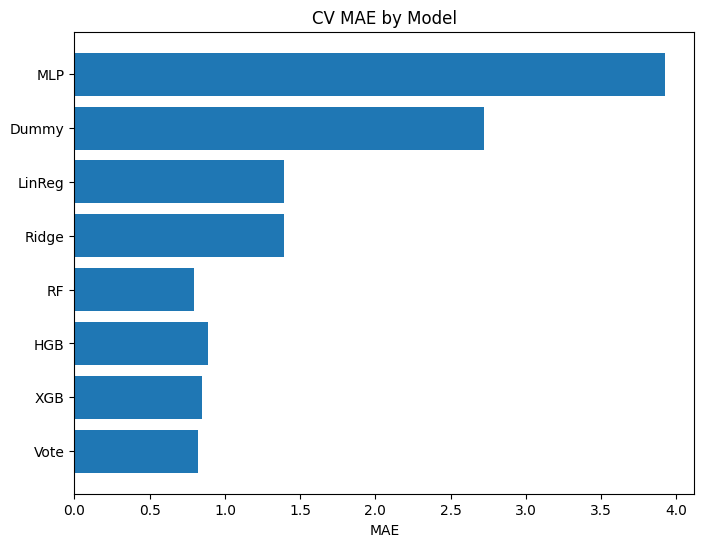

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(score_df.index, score_df['MAE'])
plt.xlabel('MAE')
plt.title('CV MAE by Model')
plt.show()

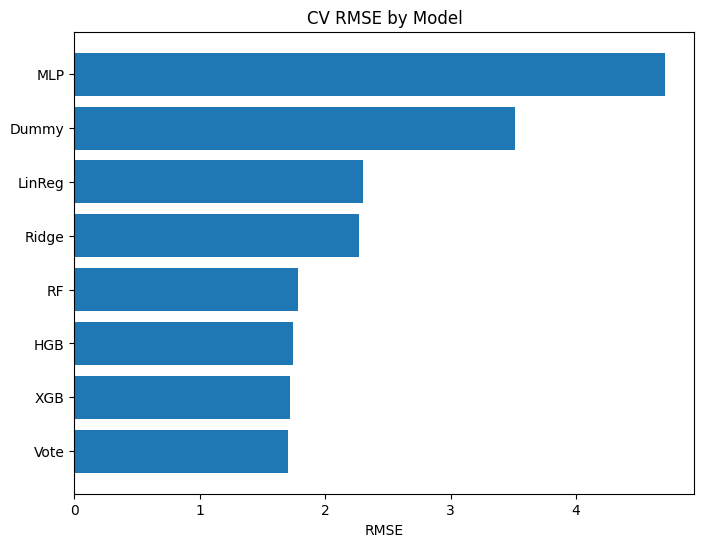

In [10]:
plt.figure(figsize=(8, 6))
plt.barh(score_df.index, score_df['RMSE'])
plt.xlabel('RMSE')
plt.title('CV RMSE by Model')
plt.show()

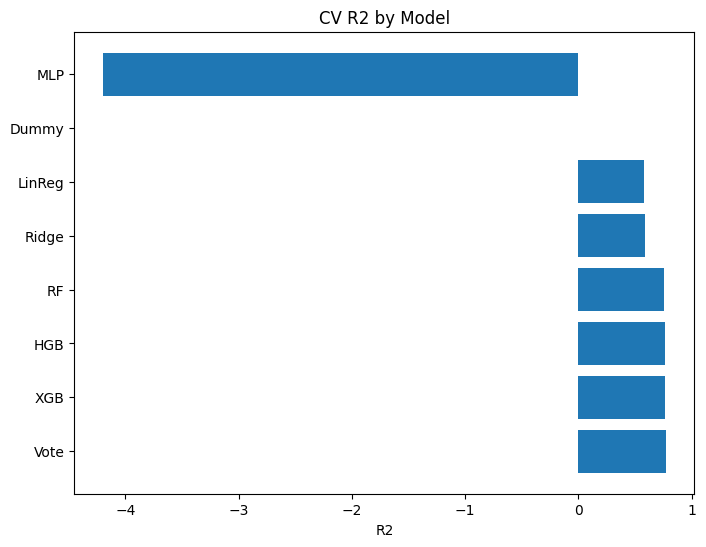

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(score_df.index, score_df['R2'])
plt.xlabel('R2')
plt.title('CV R2 by Model')
plt.show()

/var/folders/k0/5j9bhzvd0r5gddmbr7d8q2_80000gn/T/ipykernel_16179/1538227848.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=score_df.index)


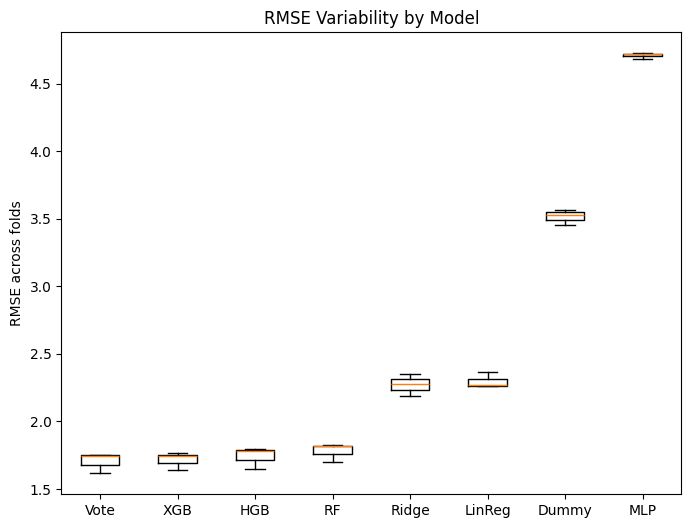

In [12]:
plt.figure(figsize=(8, 6))
data = [cv_details[m] for m in score_df.index]
plt.boxplot(data, labels=score_df.index)
plt.ylabel('RMSE across folds')
plt.title('RMSE Variability by Model')
plt.show()

Selected model: Vote


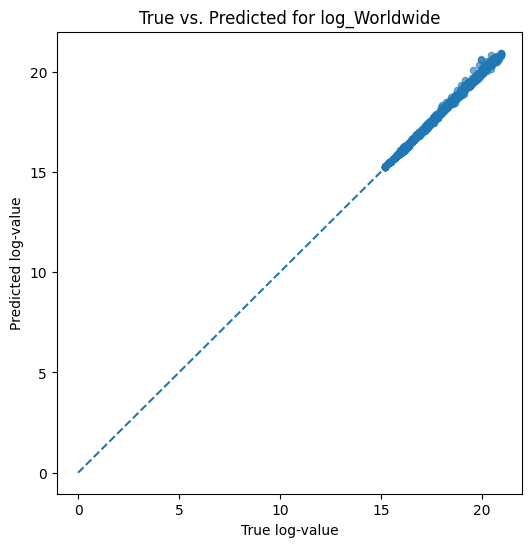

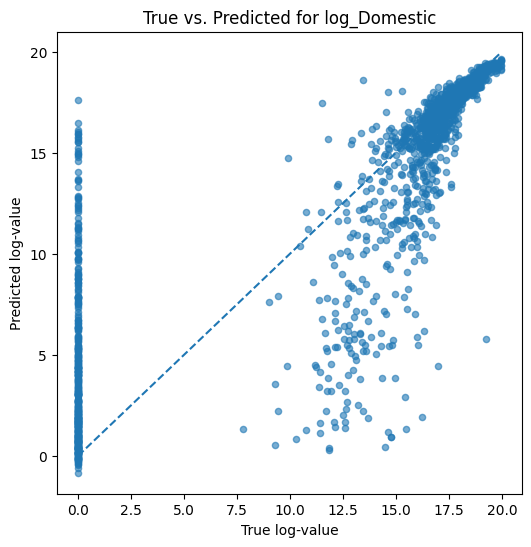

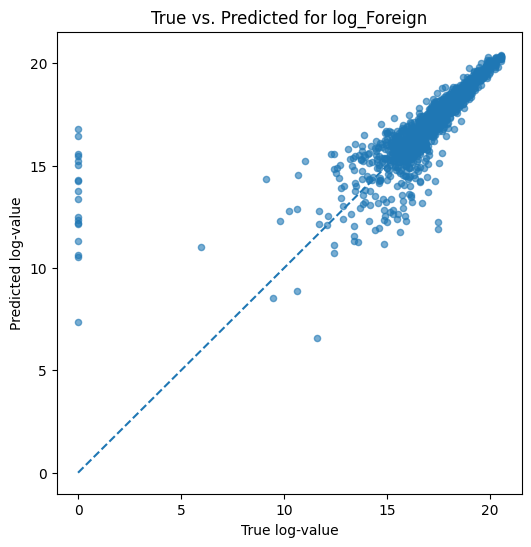

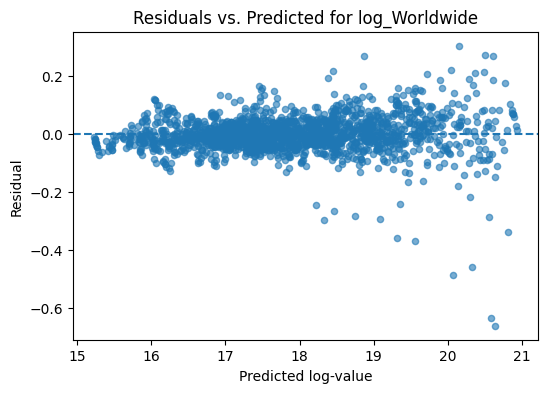

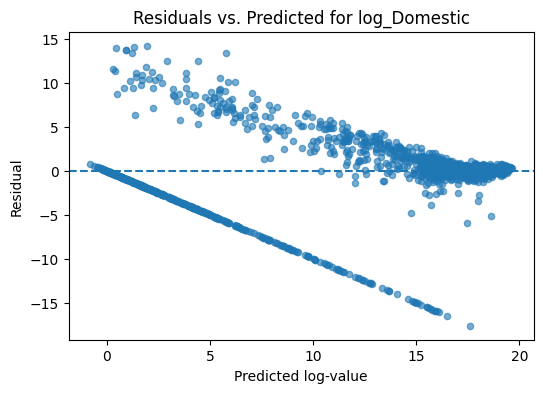

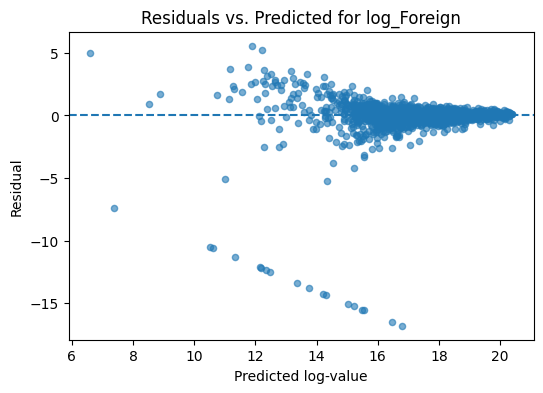

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 1. Split your data
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# 2. Decide on the “best” estimator (rebuild Vote on the fly if needed)
best_model_name = score_df.index[0]
# Print out which model was selected
print(f"Selected model: {best_model_name}")
if best_model_name == 'Vote':
    # drop existing Vote row so top3 are pure base learners
    base_scores = score_df.drop('Vote', errors='ignore')
    top3 = base_scores.head(3).index.tolist()
    estimators = [(name, models[name]) for name in top3]
    best_est = VotingRegressor(estimators=estimators)
else:
    best_est = models[best_model_name]

# 3. Wrap multioutput if needed and build pipeline
model_to_fit = (
    MultiOutputRegressor(best_est)
    if (hasattr(y, "ndim") and y.ndim > 1)
    else best_est
)
best_pipe = Pipeline([
    ('prep', preprocess),
    ('model', model_to_fit)
])

# 4. Fit & predict
best_pipe.fit(X_train_full, y_train_full)
y_pred = best_pipe.predict(X_test_full)

# 5. Diagnostic plots
for i, col in enumerate(y.columns):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test_full.iloc[:, i], y_pred[:, i], alpha=0.6, s=20)
    maxv = max(y_test_full.iloc[:, i].max(), y_pred[:, i].max())
    plt.plot([0, maxv], [0, maxv], '--')
    plt.title(f"True vs. Predicted for {col}")
    plt.xlabel("True log-value")
    plt.ylabel("Predicted log-value")
    plt.show()

residuals = y_test_full.values - y_pred
for i, col in enumerate(y.columns):
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred[:, i], residuals[:, i], alpha=0.6, s=20)
    plt.axhline(0, linestyle='--')
    plt.title(f"Residuals vs. Predicted for {col}")
    plt.xlabel("Predicted log-value")
    plt.ylabel("Residual")
    plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


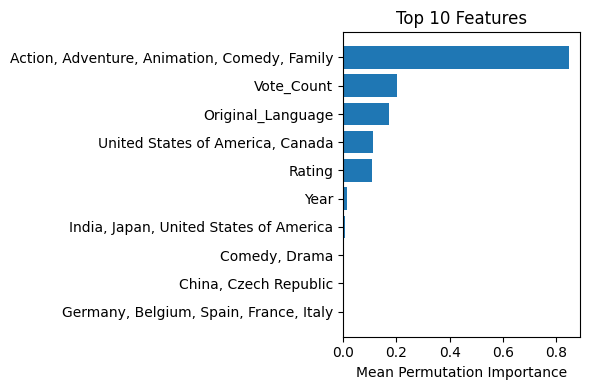

In [14]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# run fewer repeats, use all CPUs
perm_res = permutation_importance(
    best_pipe, 
    X_test_full, 
    y_test_full,
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1
)
importances = perm_res.importances_mean
feature_names  = list(cat_cols) + num_cols

# grab the indices of the top 10 features
top_k = 10
sorted_idx = np.argsort(importances)[-top_k:]

plt.figure(figsize=(6,4))
plt.barh(
    np.array(feature_names)[sorted_idx],
    importances[sorted_idx]
)
plt.xlabel("Mean Permutation Importance")
plt.title(f"Top {top_k} Features")
plt.tight_layout()
plt.show()

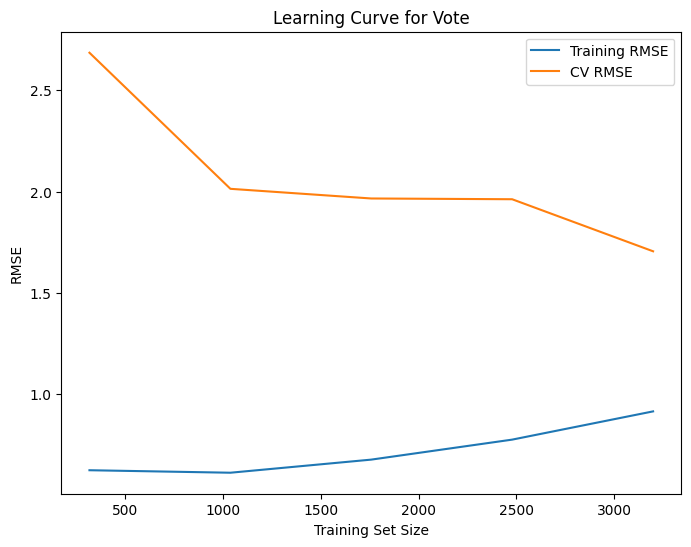

In [15]:
# Learning curve for the best model
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_pipe, X, y, cv=cv, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1,1.0,5), n_jobs=-1, random_state=42
)
train_rmse = -train_scores.mean(axis=1)
test_rmse = -test_scores.mean(axis=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_rmse, label='Training RMSE')
plt.plot(train_sizes, test_rmse, label='CV RMSE')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title(f'Learning Curve for {best_model_name}')
plt.legend()
plt.show()

## Step 7: Conclusions
- **Best performer:** Use the table above to identify and highlight the top model and its metrics.
- **Ensemble:** The VotingRegressor often combines strengths and further reduces error.
- **Diagnostics:** Residual plots and learning curves confirm fit quality and data sufficiency.
- **Next steps:** Consider domain-specific feature engineering, advanced ensembling, or deeper hyperparameter tuning for potential improvements.

## Extra's 1:  Hyperparameter Search
If further tuning is desired, you can use `RandomizedSearchCV` to optimize key hyperparameters for models like RF, HGB, XGB, and MLP.

In [16]:
from sklearn.model_selection import RandomizedSearchCV

# Example: optimize XGB
xgb_pipe = Pipeline([('prep', preprocess), ('model', XGBRegressor(random_state=42))])
param_dist = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1]
}
search = RandomizedSearchCV(
    xgb_pipe, param_dist, n_iter=20, scoring='neg_root_mean_squared_error',
    cv=cv, n_jobs=-1, random_state=42
)
search.fit(X, y)
print('Best params for XGB:', search.best_params_)
print('Best RMSE:', -search.best_score_)

Best params for XGB: {'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05}
Best RMSE: 1.7220792770385742


# Insight
With this we can choose the n estimators of 200, depth of 6 and a learning rate of 0.05

## Extra's 2: Determining Our Splits



,train_size,n_train,n_test,train_R2,test_R2
0,0.2,959,3838,0.935555,0.678951
1,0.3,1439,3358,0.906692,0.665623
2,0.4,1918,2879,0.899882,0.675156
3,0.5,2398,2399,0.889975,0.707889
4,0.6,2878,1919,0.875904,0.727003
5,0.7,3357,1440,0.867669,0.724137
6,0.8,3837,960,0.867247,0.706990


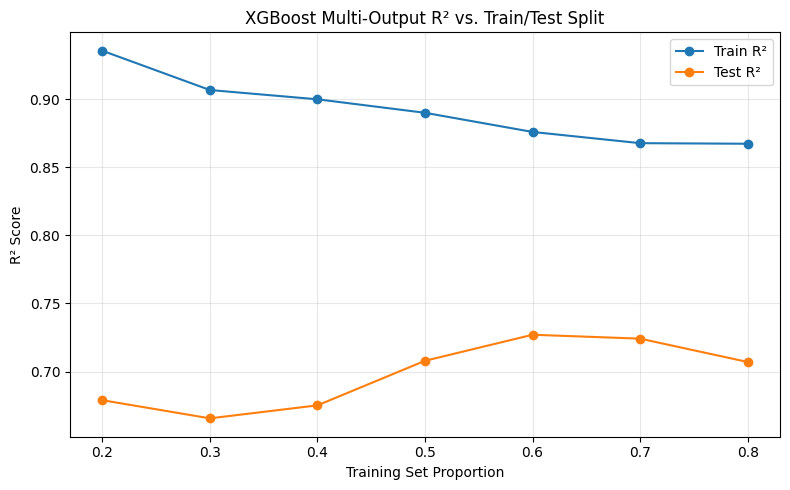

In [17]:
# — 6) Evaluate XGBoost over multiple train/test splits (parallel + smaller models) —
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection   import train_test_split
from sklearn.multioutput      import MultiOutputRegressor
from sklearn.metrics          import r2_score
import xgboost as xgb

split_results = []
train_sizes = np.arange(0.2, 0.4, 0.9, 0.1)   # 20% → 80% train

for ts in train_sizes:
    # 6a) split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        train_size=ts,
        random_state=42,
        shuffle=True
    )
    # 6b) fit/transform pipeline
    X_tr_p = pipeline.fit_transform(X_tr)
    X_te_p = pipeline.transform(X_te)
    
    # 6c) lighter, parallel XGB + parallel multi-output
    xgb_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=50,       # fewer trees
        max_depth=4,           # shallower
        n_jobs=-1,             # use all cores
        random_state=42,
        verbosity=0
    )
    model = MultiOutputRegressor(xgb_reg, n_jobs=-1)
    model.fit(X_tr_p, y_tr)
    
    # 6d) record R² on train & test
    y_tr_pred = model.predict(X_tr_p)
    y_te_pred = model.predict(X_te_p)
    split_results.append({
        'train_size': ts,
        'n_train'   : X_tr_p.shape[0],
        'n_test'    : X_te_p.shape[0],
        'train_R2'  : r2_score(y_tr, y_tr_pred),
        'test_R2'   : r2_score(y_te, y_te_pred)
    })

# 6e) summarize results
split_df = pd.DataFrame(split_results)
display(split_df)

# 6f) plot
plt.figure(figsize=(8,5))
plt.plot(split_df['train_size'], split_df['train_R2'], marker='o', label='Train R²')
plt.plot(split_df['train_size'], split_df['test_R2'],  marker='o', label='Test R²')
plt.xlabel('Training Set Proportion')
plt.ylabel('R² Score')
plt.title('XGBoost Multi-Output R² vs. Train/Test Split')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Insight
Based on the above we can see that the testing set performed the best for XGBOOST.  Based on this I will be splitting the training data 60/40 for all of the models.